In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import ( r2_score,mean_absolute_error,mean_squared_error)

# Load Dataset
df = pd.read_csv("Live.csv")

In [2]:
print("Shape of Dataset:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(include='object').columns

print("\nNumerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

Shape of Dataset:
(500, 11)

First 5 Rows:
   status_id status_type  num_reactions  num_comments  num_shares  num_likes  \
0          1       video            308           369         127         72   
1          2      status           4010           672         137       2789   
2          3      status            117            43         146       2672   
3          4      status           4260           163         347       1267   
4          5       photo           1988           768         250        358   

   num_loves  num_wows  num_hahas  num_sads  num_angrys  
0        605       284        177         9           3  
1        859       106        181        88          49  
2        761       288        133        11          42  
3        664        33        102        61          16  
4        854        54        114        53           6  

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 

In [3]:

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nDuplicates Before:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

df.reset_index(drop=True,inplace=True)

print("\nDuplicates After:")
print(df.duplicated().sum())

numeric_convert = ['num_reactions','num_comments','num_shares']

for col in numeric_convert:

    df[col] = pd.to_numeric(df[col],errors='coerce')

df['status_type'] = ( df['status_type'].str.strip().str.lower())

df['num_reactions'] = (df['num_reactions'].abs())

df.columns = (df.columns.str.lower().str.replace(" ","_"))

print("\nColumn Names")
print(df.columns)

print("\nData Types")
print(df.dtypes)


Duplicates Before:
0

Duplicates After:
0

Column Names
Index(['status_id', 'status_type', 'num_reactions', 'num_comments',
       'num_shares', 'num_likes', 'num_loves', 'num_wows', 'num_hahas',
       'num_sads', 'num_angrys'],
      dtype='object')

Data Types
status_id         int64
status_type      object
num_reactions     int64
num_comments      int64
num_shares        int64
num_likes         int64
num_loves         int64
num_wows          int64
num_hahas         int64
num_sads          int64
num_angrys        int64
dtype: object


In [5]:
print("\nStatistical Summary")
print(df.describe())

print("\nMean")
print(df[num_cols].mean())

print("\nMedian")
print(df[num_cols].median())

print("\nStandard Deviation")
print(df[num_cols].std())

for col in cat_cols:

    print(f"\nValue Counts of {col}")

    print(df[col].value_counts())

print("\nFinal Missing Values")
print(df.isnull().sum())

print("\nFinal Shape")
print(df.shape)

df.to_csv("cleaned_live_dataset.csv",index=False)

print("\nCleaned Dataset Saved Successfully")


Statistical Summary
        status_id  num_reactions  num_comments  num_shares   num_likes  \
count  500.000000     500.000000    500.000000  500.000000   500.00000   
mean   250.500000    2611.678000    472.246000  251.670000  2023.44600   
std    144.481833    1462.404349    288.588288  144.155036  1140.28821   
min      1.000000      72.000000     10.000000    7.000000    22.00000   
25%    125.750000    1268.750000    197.750000  127.750000  1128.00000   
50%    250.500000    2581.500000    473.000000  248.000000  2050.00000   
75%    375.250000    3919.000000    717.000000  380.000000  3009.75000   
max    500.000000    4999.000000   1000.000000  500.000000  3993.00000   

        num_loves    num_wows   num_hahas    num_sads  num_angrys  
count  500.000000  500.000000  500.000000  500.000000   500.00000  
mean   498.524000  153.118000   98.838000   50.262000    25.30000  
std    290.809838   86.881049   58.577559   29.409236    14.74343  
min      0.000000    0.000000    0.00000

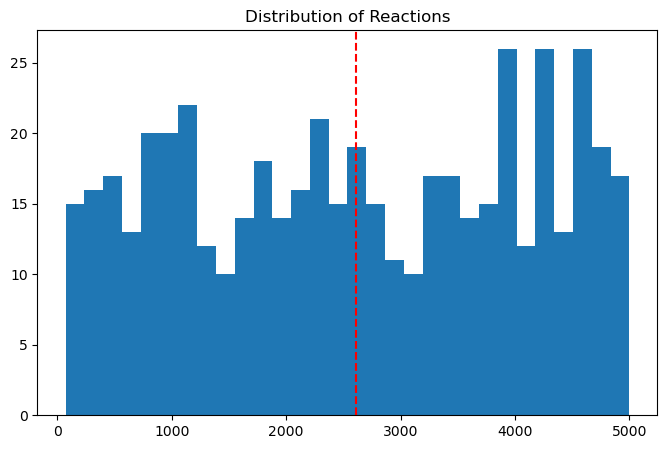

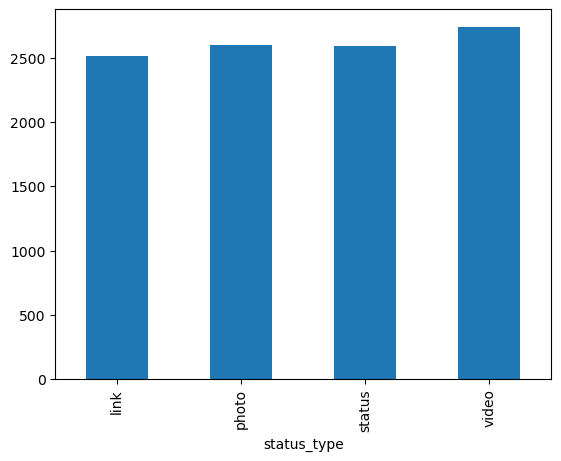

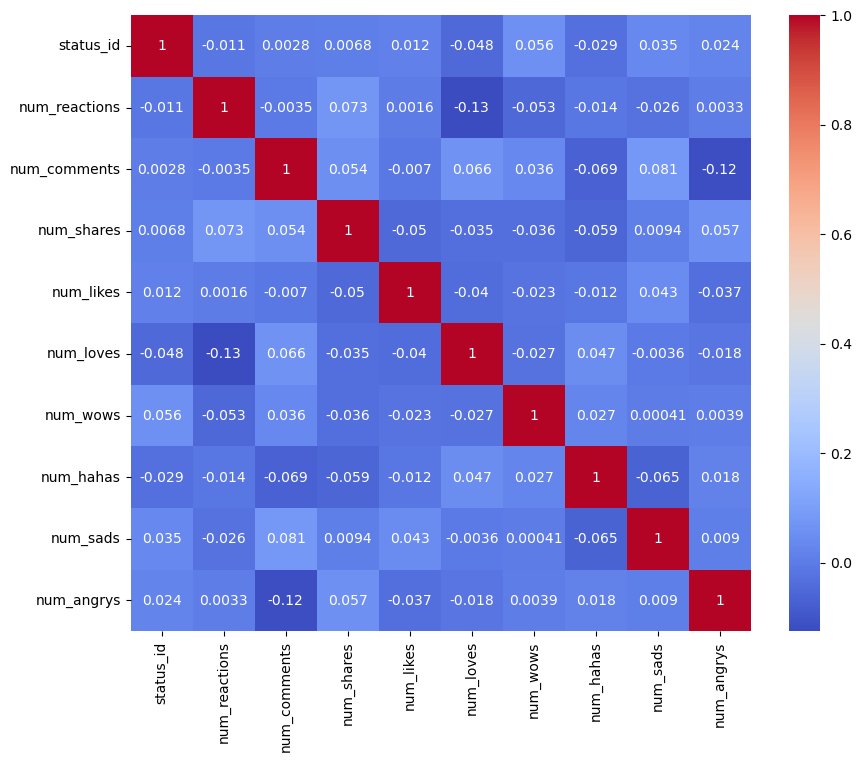

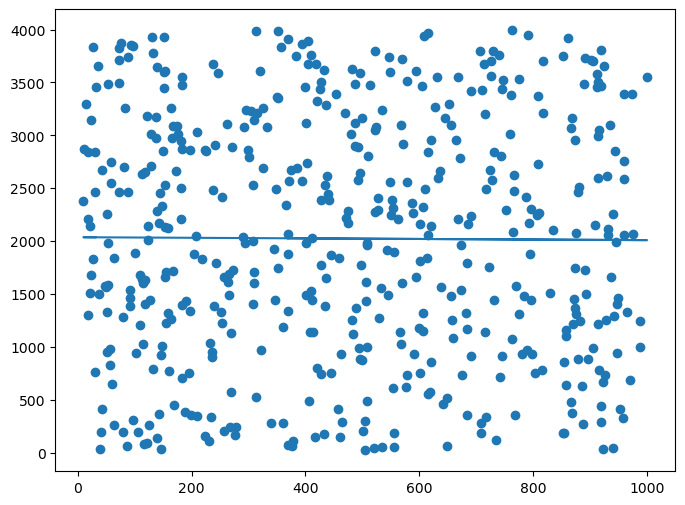

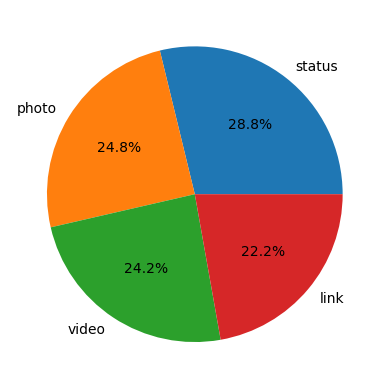

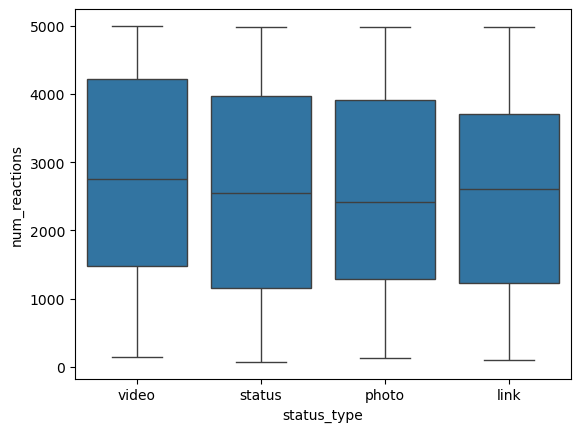

In [6]:
df = pd.read_csv("cleaned_live_dataset.csv")

plt.figure(figsize=(8,5))

plt.hist(df['num_reactions'], bins=30)

mean = df['num_reactions'].mean()

plt.axvline(mean,color='red',linestyle='--')

plt.title("Distribution of Reactions")

plt.show()

avg = df.groupby('status_type')['num_reactions'].mean()

avg.plot(kind='bar')

plt.show()

plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap( corr,annot=True,cmap='coolwarm')

plt.show()

plt.figure(figsize=(8,6))

plt.scatter( df['num_comments'],df['num_likes'])

m,b=np.polyfit(df['num_comments'],df['num_likes'], 1)

plt.plot(df['num_comments'],m*df['num_comments']+b)

plt.show()

counts = (df['status_type'].value_counts())

plt.pie(counts,labels=counts.index,autopct='%1.1f%%')

plt.show()

sns.boxplot(x='status_type',y='num_reactions',data=df)

plt.show()

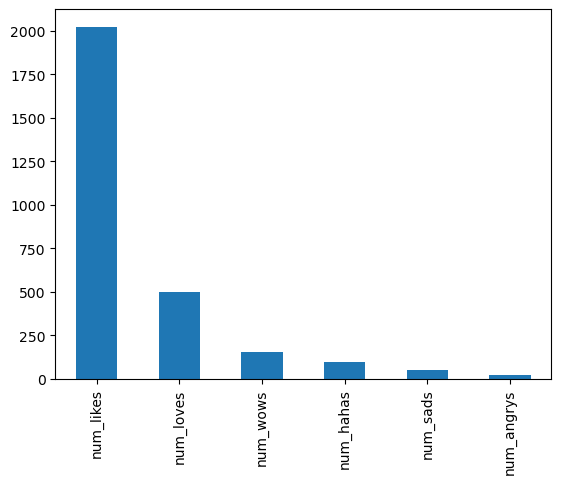

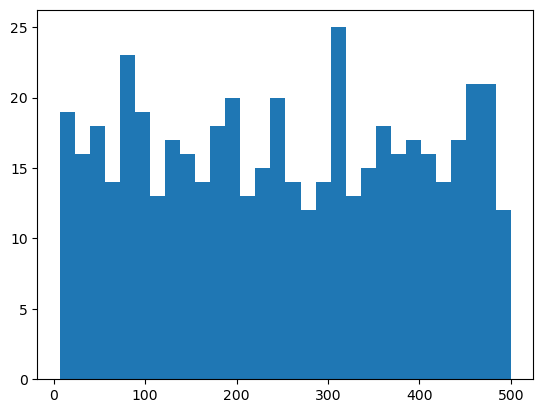

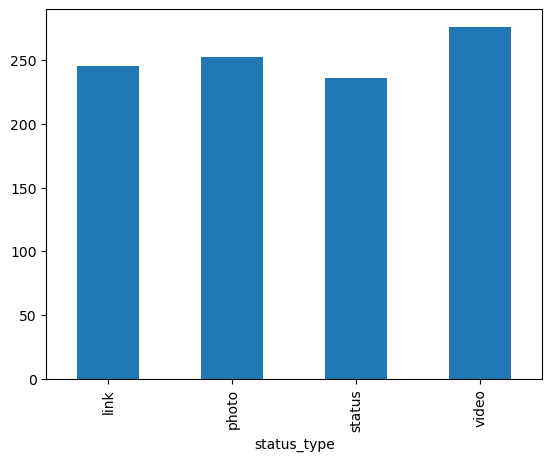

EDA Complete


In [7]:
reaction_cols = ['num_likes','num_loves','num_wows','num_hahas','num_sads','num_angrys']

avg = df[reaction_cols].mean()

avg.plot(kind='bar')

plt.show()

plt.hist(df['num_shares'],bins=30)

plt.show()

avg_share = df.groupby( 'status_type')['num_shares'].mean()

avg_share.plot(kind='bar')

plt.show()

print("EDA Complete")

In [8]:
print("\nProbability Analysis")

p_likes=(df['num_likes']>1000).mean()

print("Likes >1000:",p_likes)

p_shares=(df['num_shares']>100).mean()

print("Shares >100:",p_shares)

mean=df['num_reactions'].mean()

std=df['num_reactions'].std()

n=len(df)

critical=stats.norm.ppf(0.975)

margin=critical*(std/np.sqrt(n))

print("95% Confidence Interval")

print(mean-margin,mean+margin)

video=df[df['status_type']=='video']['num_reactions']

photo=df[df['status_type']=='photo']['num_reactions']

t,p=stats.ttest_ind(video,photo,equal_var=False)

print("T-test p value:",p)

status=df[df['status_type']=="status"]['num_reactions']

link=df[df['status_type']=="link"]['num_reactions']

F,p=stats.f_oneway(video,photo,status,link)

print("ANOVA p value:",p)


Probability Analysis
Likes >1000: 0.766
Shares >100: 0.79
95% Confidence Interval
2483.4949624873925 2739.8610375126073
T-test p value: 0.4667221917324035
ANOVA p value: 0.6985598862551451


R2: -0.004304107446520211
MAE: 937.4575332061659
RMSE: 1119.1785401170296


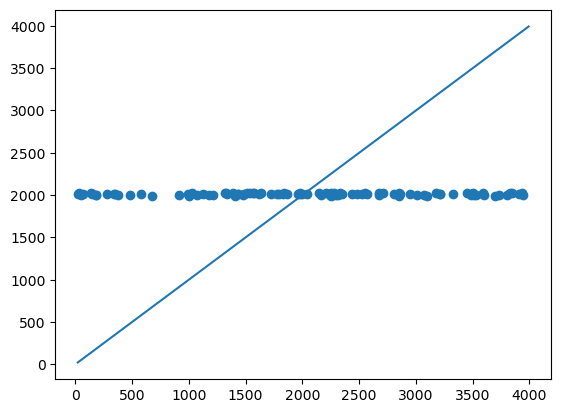

In [9]:

X=df[['num_comments']]

y=df['num_likes']

X_train,X_test,y_train,y_test=(train_test_split(X,y,test_size=0.20,random_state=42))

model=LinearRegression()

model.fit(X_train,y_train)

y_pred=model.predict(X_test)

print("R2:",r2_score(y_test,y_pred))

print("MAE:",mean_absolute_error(y_test,y_pred))

print("RMSE:",np.sqrt(mean_squared_error(y_test,y_pred)))

plt.scatter(y_test,y_pred)

plt.plot([y.min(),y.max()],[y.min(),y.max()])

plt.show()

R2: 0.007056212215567181
MAE: 927.9537884097005
RMSE: 1112.8306693140723


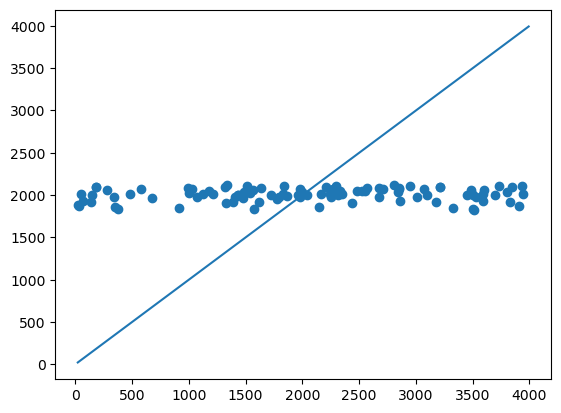

PROJECT COMPLETED SUCCESSFULLY


In [10]:

df['is_video']=(df['status_type']=="video").astype(int)

features=['num_comments','num_shares','is_video']

X=df[features]

y=df['num_likes']

X_train,X_test,y_train,y_test=(train_test_split(X,y,test_size=0.20,random_state=42))

model2=LinearRegression()

model2.fit(X_train,y_train)

prediction=model2.predict(X_test)

print("R2:",r2_score(y_test,prediction))

print("MAE:",mean_absolute_error(y_test,prediction))

print("RMSE:",np.sqrt(mean_squared_error(y_test,prediction)))


plt.scatter(y_test,prediction)

plt.plot([y.min(),y.max()],[y.min(),y.max()])

plt.show()

print("PROJECT COMPLETED SUCCESSFULLY")